<a href="https://colab.research.google.com/github/marcomunozq-miaad-uacj/Programacion1Semestre/blob/Programacion1Sem/Practica_28_Selecci%C3%B3n_y_Generaci%C3%B3n_de_Prototipos_Pr%C3%A1ctica_usando_Breast_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ==========================================================================
# 📝 Tarea: Reducción de la Numerosidad con CNN, ENN y K-medias usando SVM
# 📊 Dataset: Breast Cancer (Scikit-Learn)
# 👤 Autor/a: Marco Antonio Muñoz Quiroz
# 📅 Fecha: 07 de noviembre de 2025
# ==========================================================================

## 🔍 Descripción:
En este cuaderno aplicarás técnicas de reducción de la numerosidad (CNN, ENN, K-medias) al conjunto de datos Breast Cancer y analizarás su efecto en el rendimiento de un modelo SVM.

## ==========================================================================

## 1. Cargar librerías necesarias
Escribe aquí la importación de librerías: numpy, pandas, matplotlib, seaborn, sklearn (datasets, model_selection, preprocessing, metrics, svm, kmeans), etc.

En el caso de los códigos de ENN, CNN, estos  deberás tomarlos del cuaderno que contiene la teoría y ejemplos.

In [1]:
#1. Cargar librerías necesarias
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.under_sampling import CondensedNearestNeighbour

# --------------------------------------------------------------------------

## 2. Cargar y explorar el conjunto de datos Breast Cancer
- Cargar el dataset con sklearn.datasets.load_breast_cancer
- Explora las dimensiones, variables, y distribución de clases

Dimensiones del dataset: (569, 31)

Variables numéricas disponibles:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

Distribución de clases (0 = Maligno, 1 = Benigno):
target
1    357
0    212
Name: count, dtype: int64


/tmp/ipython-input-3284600083.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=clase_counts.index, y=clase_counts.values, palette="pastel")


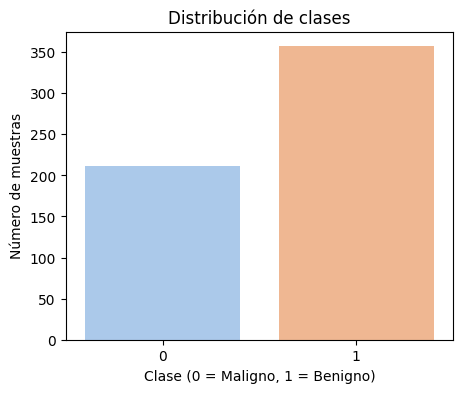


== Descripción general de las variables ==


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [2]:
# Cargo el dataset
data = load_breast_cancer()

# Creo un DataFrame con las variables
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# == Exploración inicial ==
print("Dimensiones del dataset:", df.shape)
print("\nVariables numéricas disponibles:")
print(df.columns[:-1].tolist())

# Distribución de clases
clase_counts = df['target'].value_counts()
print("\nDistribución de clases (0 = Maligno, 1 = Benigno):")
print(clase_counts)

# Visualizo la proporción de clases
plt.figure(figsize=(5,4))
sns.barplot(x=clase_counts.index, y=clase_counts.values, palette="pastel")
plt.title("Distribución de clases")
plt.xlabel("Clase (0 = Maligno, 1 = Benigno)")
plt.ylabel("Número de muestras")
plt.show()

# Estadísticas generales
print("\n== Descripción general de las variables ==")
display(df.describe())


# --------------------------------------------------------------------------

## 3. Preprocesamiento
 - Escalamiento de características (StandardScaler)
 - División del conjunto en entrenamiento y prueba
 - usar hold-out de 70% y 30%



In [3]:
# Cargo el dataset en un DataFrame
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")  # 0=maligno, 1=benigno

# Divido en entrenamiento/prueba con hold-out 70/30, estratificando para mantener proporción de clases
# Fijo random_state para reproducibilidad
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=13
)

# Escalamiento de características con StandardScaler
# Ajusto (fit) SOLO con X_train para evitar fuga de información
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convierto a DataFrame para mantener nombres (opcional pero útil para inspección)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns, index=X_test.index)

# Reporto tamaños y distribución de clases
print("=== Dimensiones ===")
print(f"Total: X={X.shape}, y={y.shape}")
print(f"Train: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test : X_test={X_test.shape},  y_test={y_test.shape}")

print("\n=== Distribución de clases (0=maligno, 1=benigno) ===")
print("Global:\n", y.value_counts(normalize=True).round(3))
print("\nTrain:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest:\n", y_test.value_counts(normalize=True).round(3))

# Verificación rápida del escalado: media≈0 y std≈1 SOLO en el set de entrenamiento
train_means = X_train_scaled.mean().round(3)
train_stds  = X_train_scaled.std(ddof=0).round(3)

print("\n=== Verificación del escalado en TRAIN ===")
print("Media promedio (esperada ~0):", float(train_means.mean()))
print("Desv. estándar promedio (esperada ~1):", float(train_stds.mean()))

# Muestro las primeras filas de X_train_scaled
print("\nPrimeras filas de X_train_scaled:")
display(X_train_scaled.head())


=== Dimensiones ===
Total: X=(569, 30), y=(569,)
Train: X_train=(398, 30), y_train=(398,)
Test : X_test=(171, 30),  y_test=(171,)

=== Distribución de clases (0=maligno, 1=benigno) ===
Global:
 target
1    0.627
0    0.373
Name: proportion, dtype: float64

Train:
 target
1    0.628
0    0.372
Name: proportion, dtype: float64

Test:
 target
1    0.626
0    0.374
Name: proportion, dtype: float64

=== Verificación del escalado en TRAIN ===
Media promedio (esperada ~0): 0.0
Desv. estándar promedio (esperada ~1): 1.0

Primeras filas de X_train_scaled:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
243,-0.111831,1.045437,-0.146890,-0.186169,-1.097520,-0.672579,-0.521653,-0.650434,-0.142327,-1.211262,...,-0.266331,0.088193,-0.284196,-0.308921,-1.656426,-0.700825,-0.657389,-0.834214,-0.423262,-1.122874
158,-0.591123,-1.564835,-0.625937,-0.583038,-0.188382,-0.959750,-0.850665,-0.747078,-0.811333,-0.524267,...,-0.655926,-1.207898,-0.698149,-0.614665,-0.195133,-0.826244,-0.881486,-0.695654,-0.659483,-0.294663
205,0.276708,-0.632426,0.272379,0.169160,-0.500270,-0.162602,-0.177186,-0.210337,-0.796710,-0.410726,...,0.308687,-0.908800,0.301644,0.191532,0.738159,0.427348,0.232849,0.132843,0.768937,0.672720
125,-0.083470,-0.507000,-0.150984,-0.189818,-0.565516,-0.795626,-0.917313,-0.955586,-0.723594,-0.548700,...,-0.166328,-0.362906,-0.215798,-0.273792,-0.704987,-0.755770,-0.905054,-0.985289,-0.897288,-0.670693
309,-0.310354,-1.304517,-0.385595,-0.352888,-0.875971,-1.235919,-1.033717,-1.021055,-1.312173,-1.083349,...,-0.324666,-1.372974,-0.404337,-0.368234,-1.314219,-1.212832,-1.189631,-1.222304,-1.304729,-0.986852


# --------------------------------------------------------------------------

## 4. Aplicar técnica CNN (Condensed Nearest Neighbor)

- Aplicar CNN sobre el conjunto de entrenamiento
- Mostrar el tamaño del conjunto reducido



In [4]:
#4. Aplicar técnica CNN (Condensed Nearest Neighbor)
# Aplico CNN sobre el set de entrenamiento escalado
# Uso n_neighbors=1 (defecto) con métrica euclidiana, y random_state para reproducibilidad
cnn = CondensedNearestNeighbour(n_neighbors=1, random_state=42)
X_train_cnn, y_train_cnn = cnn.fit_resample(X_train_scaled, y_train)

# Reporto tamaños antes y después
n_before = X_train_scaled.shape[0]
n_after  = X_train_cnn.shape[0]
reduction_pct = 100 * (1 - n_after / n_before)

print("=== CNN aplicado solo en TRAIN ===")
print(f"Tamaño original del train: {n_before} muestras")
print(f"Tamaño tras CNN        : {n_after} muestras")
print(f"Reducción porcentual   : {reduction_pct:.2f}%")

# Distribución de clases antes y después
print("\n=== Distribución de clases (0=maligno, 1=benigno) ===")
dist_before = y_train.value_counts().sort_index()
dist_after  = y_train_cnn.value_counts().sort_index()
print("Antes (train):")
print(dist_before.to_string())
print("\nDespués (CNN train):")
print(dist_after.to_string())

# Conservo en DataFrame para facilitar inspección posterior
if isinstance(X_train_cnn, np.ndarray):
    X_train_cnn = pd.DataFrame(X_train_cnn, columns=X_train_scaled.columns)
print("\nPrimeras filas del train reducido (CNN):")
display(X_train_cnn.head())


=== CNN aplicado solo en TRAIN ===
Tamaño original del train: 398 muestras
Tamaño tras CNN        : 188 muestras
Reducción porcentual   : 52.76%

=== Distribución de clases (0=maligno, 1=benigno) ===
Antes (train):
target
0    148
1    250

Después (CNN train):
target
0    148
1     40

Primeras filas del train reducido (CNN):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0.276708,-0.632426,0.272379,0.169160,-0.500270,-0.162602,-0.177186,-0.210337,-0.796710,-0.410726,...,0.308687,-0.908800,0.301644,0.191532,0.738159,0.427348,0.232849,0.132843,0.768937,0.672720
1,1.221112,0.605264,1.149404,1.175084,-0.103060,-0.140413,0.303352,0.491789,-0.438444,-0.782968,...,1.298301,0.913572,1.131336,1.251575,0.625818,-0.203330,0.521452,0.324324,0.283813,-0.445916
2,0.322085,0.723590,0.278111,0.152320,-0.370496,0.008307,-0.439793,-0.417322,-0.310492,0.064997,...,0.314937,0.364409,0.185666,0.162582,-0.082792,0.408236,0.369913,0.093642,0.388448,0.689526
3,-0.211093,0.276318,-0.142796,-0.279633,1.065626,0.772997,0.655909,0.827887,1.111602,1.513723,...,0.025345,0.630818,0.170797,-0.064608,1.096785,0.740895,1.037591,1.337517,1.038450,1.381714
4,0.866606,1.222926,0.903739,0.766427,0.814681,1.434994,0.954133,0.770053,0.420661,0.309326,...,1.464973,1.310735,1.309764,1.412215,1.144314,2.853904,1.698031,1.108343,0.607229,2.589630


 --------------------------------------------------------------------------

## 5. Aplicar técnica ENN (Edited Nearest Neighbor)

- Aplicar ENN sobre el conjunto de entrenamiento
- Mostrar el tamaño del conjunto reducido



In [5]:
# Aplico ENN en el set de entrenamiento escalado
# Uso n_neighbors=3 (valor típico); este método elimina ejemplos cuya etiqueta no coincide con la mayoría de sus vecinos
enn = EditedNearestNeighbours(n_neighbors=3)
X_train_enn, y_train_enn = enn.fit_resample(X_train_scaled, y_train)

# Reporto tamaños y reducción
n_before = X_train_scaled.shape[0]
n_after  = X_train_enn.shape[0]
reduction_pct = 100 * (1 - n_after / n_before)

print("=== ENN aplicado solo en TRAIN ===")
print(f"Tamaño original del train: {n_before} muestras")
print(f"Tamaño tras ENN        : {n_after} muestras")
print(f"Reducción porcentual   : {reduction_pct:.2f}%")

# Distribución de clases antes y después
print("\n=== Distribución de clases (0=maligno, 1=benigno) ===")
print("Antes (train):")
print(y_train.value_counts().sort_index().to_string())
print("\nDespués (ENN train):")
print(y_train_enn.value_counts().sort_index().to_string())

# Me aseguro de mantener DataFrame con nombres de columnas
if isinstance(X_train_enn, np.ndarray):
    X_train_enn = pd.DataFrame(X_train_enn, columns=X_train_scaled.columns)

print("\nPrimeras filas del train reducido (ENN):")
display(X_train_enn.head())

=== ENN aplicado solo en TRAIN ===
Tamaño original del train: 398 muestras
Tamaño tras ENN        : 371 muestras
Reducción porcentual   : 6.78%

=== Distribución de clases (0=maligno, 1=benigno) ===
Antes (train):
target
0    148
1    250

Después (ENN train):
target
0    148
1    223

Primeras filas del train reducido (ENN):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0.276708,-0.632426,0.272379,0.169160,-0.500270,-0.162602,-0.177186,-0.210337,-0.796710,-0.410726,...,0.308687,-0.908800,0.301644,0.191532,0.738159,0.427348,0.232849,0.132843,0.768937,0.672720
1,1.221112,0.605264,1.149404,1.175084,-0.103060,-0.140413,0.303352,0.491789,-0.438444,-0.782968,...,1.298301,0.913572,1.131336,1.251575,0.625818,-0.203330,0.521452,0.324324,0.283813,-0.445916
2,0.322085,0.723590,0.278111,0.152320,-0.370496,0.008307,-0.439793,-0.417322,-0.310492,0.064997,...,0.314937,0.364409,0.185666,0.162582,-0.082792,0.408236,0.369913,0.093642,0.388448,0.689526
3,-0.211093,0.276318,-0.142796,-0.279633,1.065626,0.772997,0.655909,0.827887,1.111602,1.513723,...,0.025345,0.630818,0.170797,-0.064608,1.096785,0.740895,1.037591,1.337517,1.038450,1.381714
4,0.866606,1.222926,0.903739,0.766427,0.814681,1.434994,0.954133,0.770053,0.420661,0.309326,...,1.464973,1.310735,1.309764,1.412215,1.144314,2.853904,1.698031,1.108343,0.607229,2.589630


# --------------------------------------------------------------------------

## 6. Aplicar reducción mediante K-medias
- Realizar agrupamiento por clase y representar cada grupo con su centroide. Elige la mitad de los elementos de cada clase como el valor del número de centroides
- Generar un nuevo conjunto reducido con los centroides como prototipos



In [6]:
# K-medias por clase con k = ceil(n_clase / 2)
X_reduced_list = []
y_reduced_list = []

print("=== K-medias por clase (centroides como prototipos) ===")
n_before = X_train_scaled.shape[0]

for c in sorted(y_train.unique()):
    Xc = X_train_scaled[y_train == c]
    n_c = Xc.shape[0]
    k_c = int(np.ceil(n_c * 0.5))
    k_c = max(1, min(k_c, n_c))  # aseguro 1 <= k <= n_c

    print(f"Clase {c}: n={n_c}, k={k_c}")

    # Uso n_init=10 para compatibilidad amplia con distintas versiones de scikit-learn
    km = KMeans(n_clusters=k_c, random_state=42, n_init=10)
    km.fit(Xc.values)

    centers = km.cluster_centers_
    X_reduced_list.append(pd.DataFrame(centers, columns=X_train_scaled.columns))
    y_reduced_list.append(pd.Series([c] * k_c, name="target"))

# Conjunto reducido basado en centroides
X_train_km = pd.concat(X_reduced_list, axis=0, ignore_index=True)
y_train_km = pd.concat(y_reduced_list, axis=0, ignore_index=True)

n_after = X_train_km.shape[0]
reduction_pct = 100 * (1 - n_after / n_before)

print("\n=== Resumen de la reducción ===")
print(f"Tamaño original del train: {n_before} muestras")
print(f"Tamaño tras K-medias     : {n_after} muestras")
print(f"Reducción porcentual     : {reduction_pct:.2f}%")

print("\n=== Distribución de clases en el conjunto reducido (0=maligno, 1=benigno) ===")
print(y_train_km.value_counts().sort_index().to_string())

print("\nPrimeras filas del train reducido (centroides):")
display(X_train_km.head())


=== K-medias por clase (centroides como prototipos) ===
Clase 0: n=148, k=74
Clase 1: n=250, k=125

=== Resumen de la reducción ===
Tamaño original del train: 398 muestras
Tamaño tras K-medias     : 199 muestras
Reducción porcentual     : 50.00%

=== Distribución de clases en el conjunto reducido (0=maligno, 1=benigno) ===
target
0     74
1    125

Primeras filas del train reducido (centroides):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.067966,0.394644,1.321370,0.947741,1.954689,2.803001,2.761587,1.793818,1.100635,1.211905,...,0.939956,0.323548,1.250288,0.746709,2.388703,1.971791,2.814447,1.206345,0.499424,1.849125
1,0.526989,0.047949,0.610988,0.374751,0.510142,1.198436,1.228511,1.033287,0.391415,0.280940,...,0.354522,-0.097313,0.488994,0.199873,0.461628,1.131186,1.214462,1.131335,0.101496,0.483523
2,1.370005,0.617097,1.354125,1.301386,-0.540780,0.673972,0.223665,0.386267,0.175725,-0.669427,...,1.596227,1.211853,1.671081,1.587859,0.388175,1.551937,0.650148,1.076680,0.802230,0.570572
3,3.960735,-0.208819,3.945894,5.171836,1.323741,0.859185,2.776075,2.800842,-0.599298,-1.073288,...,2.462920,-1.198092,2.407098,2.856203,-0.769799,-0.656630,0.175852,0.649993,-2.032414,-1.540918
4,-0.014460,0.605264,-0.059133,-0.095513,-0.346358,-0.610475,-0.277339,-0.248513,-0.777212,-0.720688,...,0.111111,0.957974,0.027757,0.006738,0.079958,-0.491893,-0.047537,0.076077,-0.470823,-0.547626


 --------------------------------------------------------------------------

##7. Entrenar SVM sobre cada conjunto reducido
- Entrenar un modelo SVM (SVC) sobre:
 * los datos originales
 * datos reducidos con CNN
 * datos reducidos con ENN
 * datos reducidos con K-medias
- Evaluar cada modelo con accuracy, F1-score



In [8]:
def train_eval_svm(Xtr, ytr, Xte, yte, label):
    # Uso SVC con kernel RBF; dejo hiperparámetros por defecto para comparar escenarios de reducción
    clf = SVC(kernel="rbf", random_state=42)
    clf.fit(Xtr, ytr)
    ypred = clf.predict(Xte)
    acc = accuracy_score(yte, ypred)
    f1m = f1_score(yte, ypred, average="macro")
    f1_0, f1_1 = f1_score(yte, ypred, average=None, labels=[0, 1])
    return {
        "escenario": label,
        "train_n": Xtr.shape[0],
        "accuracy": acc,
        "f1_macro": f1m,
        "f1_0": f1_0,
        "f1_1": f1_1,
    }

resultados = []
resultados.append(train_eval_svm(X_train_scaled, y_train, X_test_scaled, y_test, "Original"))
resultados.append(train_eval_svm(X_train_cnn,    y_train_cnn, X_test_scaled, y_test, "CNN"))
resultados.append(train_eval_svm(X_train_enn,    y_train_enn, X_test_scaled, y_test, "ENN"))
resultados.append(train_eval_svm(X_train_km,     y_train_km,  X_test_scaled, y_test, "K-medias"))

res_df = pd.DataFrame(resultados).sort_values(by="f1_macro", ascending=False)

print("=== Métricas en TEST (ordenado por F1-macro) ===")
display(res_df.style.format({"accuracy":"{:.4f}", "f1_macro":"{:.4f}", "f1_0":"{:.4f}", "f1_1":"{:.4f}"}))


=== Métricas en TEST (ordenado por F1-macro) ===


,escenario,train_n,accuracy,f1_macro,f1_0,f1_1
0,Original,398,0.9883,0.9874,0.9841,0.9907
2,ENN,371,0.9708,0.9691,0.9618,0.9763
3,K-medias,199,0.9708,0.9683,0.9593,0.9772
1,CNN,188,0.9532,0.9509,0.9403,0.9615


# --------------------------------------------------------------------------

## 📊 8. Comparar los resultados y reflexión final
- Comparar las métricas de rendimiento obtenidas con cada técnica
- Escribe tus conclusiones sobre el impacto de la reducción de la numerosidad
- ¿Cuál técnica funcionó mejor? ¿Qué ventajas y desventajas observaste?



* ENN logró casi el mismo rendimiento (F1-macro = 0.9691) con poca pérdida y una reducción moderada (398 → 371).

* K-medias redujo el tamaño a la mitad (398 → 199) con un F1-macro muy similar (0.9683), siendo un buen equilibrio entre eficiencia y precisión.

* CNN tuvo la mayor reducción (398 → 188) pero también la mayor caída (F1-macro = 0.9509).

* La mejor tecnica es ENN, por mantener alto rendimiento con mínima pérdida.

La técnica ENN (Edited Nearest Neighbours) sirve para limpiar el conjunto de datos quitando los ejemplos que parecen estar mal ubicados o que no coinciden con la mayoría de sus vecinos.
- Su ventaja principal es que ayuda a reducir el ruido y mejora la calidad del entrenamiento sin afectar demasiado el desempeño del modelo. Además, conserva la mayoría de los datos importantes, por lo que el modelo sigue aprendiendo bien las diferencias entre las clases.
- Por otro lado, su desventaja es que no reduce mucho el tamaño del conjunto, así que el ahorro en tiempo o memoria no es tan grande. También puede llegar a eliminar algunos casos de la clase menos representada, lo que podría hacer que el modelo tenga un poco más de dificultad para reconocerla.

En general, ENN es una buena opción cuando se busca limpiar los datos y mantener un rendimiento alto sin perder demasiada información.